In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [110]:
df1=pd.read_csv('매출데이터concat_최종.csv')
df1.head()

,Unnamed: 0,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,350,20244,성수1가1동주민센터,한식음식점,"277,478,120",6557,"243,065,761","34,412,359","43,615,572","57,848,980",...,1913,304,3064,1625,22,664,1263,639,1063,1033
1,351,20244,성수1가1동주민센터,분식전문점,"165,336,405",13780,"155,846,786","9,489,619","34,753,822","36,296,803",...,3526,0,6874,5008,11,1831,2770,2555,2635,2080
2,352,20244,성수1가1동주민센터,커피-음료,"229,353,124",22434,"202,009,609","27,343,515","41,399,533","37,714,523",...,2561,145,8885,10700,20,5701,6810,3111,2093,1845
3,353,20244,성수1가1동주민센터,예술학원,"20,749,566",130,"20,749,566",0,"2,628,814","4,808,387",...,68,0,41,89,0,0,7,102,21,0
4,354,20244,성수1가1동주민센터,미용실,"51,000,000",922,"25,565,421","25,434,579","699,648","676,625",...,315,0,192,730,10,454,245,70,138,5


In [111]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 52 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       469 non-null    int64  
 1   기준_년분기_코드        469 non-null    int64  
 2   상권_코드_명          469 non-null    object 
 3   서비스_업종_코드_명      469 non-null    object 
 4   당월_매출_금액         469 non-null    float64
 5   당월_매출_건수         469 non-null    int64  
 6   주중_매출_금액         469 non-null    float64
 7   주말_매출_금액         469 non-null    float64
 8   월요일_매출_금액        469 non-null    float64
 9   화요일_매출_금액        469 non-null    float64
 10  수요일_매출_금액        469 non-null    float64
 11  목요일_매출_금액        469 non-null    float64
 12  금요일_매출_금액        469 non-null    float64
 13  토요일_매출_금액        469 non-null    float64
 14  일요일_매출_금액        469 non-null    float64
 15  시간대_00~06_매출_금액  469 non-null    float64
 16  시간대_06~11_매출_금액  469 non-null    float64
 17  시간대_11~14_매출_금액 

In [112]:
cond1=df1['기준_년분기_코드']==20253

In [113]:
df1=df1[cond1]

In [114]:
industry_map = {
    # 외식
    '한식음식점':'외식','중식음식점':'외식','일식음식점':'외식','양식음식점':'외식',
    '치킨전문점':'외식','패스트푸드점':'외식','분식전문점':'외식','호프-간이주점':'외식',

    # 카페·디저트
    '커피-음료':'카페·디저트','제과점':'카페·디저트',

    # 쇼핑·패션·뷰티
    '일반의류':'쇼핑·패션·뷰티','신발':'쇼핑·패션·뷰티','가방':'쇼핑·패션·뷰티',
    '화장품':'쇼핑·패션·뷰티','안경':'쇼핑·패션·뷰티','시계및귀금속':'쇼핑·패션·뷰티',
    '네일숍':'쇼핑·패션·뷰티','피부관리실':'쇼핑·패션·뷰티','미용실':'쇼핑·패션·뷰티',
    '운동/경기용품':'쇼핑·패션·뷰티',

    # 문화·여가·체험
    '노래방':'문화·여가·체험','PC방':'문화·여가·체험','당구장':'문화·여가·체험',
    '스포츠클럽':'문화·여가·체험','골프연습장':'문화·여가·체험',
    '스포츠 강습':'문화·여가·체험','예술학원':'문화·여가·체험',
    '서적':'문화·여가·체험', '화초':'문화·여가·체험',

    # 생활소비
    '편의점':'생활소비','슈퍼마켓':'생활소비','반찬가게':'생활소비',
    '청과상':'생활소비','육류판매':'생활소비','세탁소':'생활소비',
    '문구':'생활소비',


    # 병원
    '의약품':'병원','의료기기':'병원','일반의원':'병원',
    '치과의원':'병원','한의원':'병원',

    
    # 필수·서비스
    '가전제품':'필수·서비스','가전제품수리':'필수·서비스',
    '컴퓨터및주변장치판매':'필수·서비스','핸드폰':'필수·서비스',
    '자동차수리':'필수·서비스','자동차미용':'필수·서비스',
    '자전거 및 기타운송장비':'필수·서비스','철물점':'필수·서비스',
    '조명용품':'필수·서비스','인테리어':'필수·서비스','가구':'필수·서비스',
    '전자상거래업':'필수·서비스','여관':'필수·서비스',
    '애완동물':'필수·서비스',
    
}

df1['업종_대분류'] = df1['서비스_업종_코드_명'].map(industry_map)

df1['업종_대분류'] = df1['업종_대분류'].fillna('필수·서비스')

In [115]:
df1['업종_대분류'].isna().sum()

np.int64(0)

In [116]:
df1['업종_대분류'].value_counts()

업종_대분류
외식          29
쇼핑·패션·뷰티    21
필수·서비스      19
문화·여가·체험    15
생활소비        14
카페·디저트       9
병원           8
Name: count, dtype: int64

In [117]:
df1.head()

,Unnamed: 0,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,...,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,업종_대분류
118,468,20253,성수역 골목형상점가,한식음식점,"93,000,000",6250,"84,039,458","8,960,542","18,181,149","18,431,033",...,37,3116,2144,8,1034,2083,984,754,397,외식
119,469,20253,성수역,전자상거래업,"384,833,657",2623,"266,759,694","118,073,963",0,"74,342,866",...,0,1311,1312,0,438,437,874,437,437,필수·서비스
120,470,20253,성수역,조명용품,"57,516,968",3087,"46,897,123","10,619,845","11,999,587","12,693,490",...,8,1656,618,8,258,256,345,554,851,필수·서비스
121,471,20253,성수역,철물점,"10,736,953",1059,"9,797,369","939,584","3,344,756","1,405,360",...,0,475,219,0,0,146,74,183,293,필수·서비스
122,472,20253,성수역,화초,"73,500,827",2076,"58,179,394","15,321,433","13,293,496","13,402,014",...,163,1018,759,68,719,475,245,203,68,문화·여가·체험


In [118]:
df1.head()

,Unnamed: 0,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,...,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,업종_대분류
118,468,20253,성수역 골목형상점가,한식음식점,"93,000,000",6250,"84,039,458","8,960,542","18,181,149","18,431,033",...,37,3116,2144,8,1034,2083,984,754,397,외식
119,469,20253,성수역,전자상거래업,"384,833,657",2623,"266,759,694","118,073,963",0,"74,342,866",...,0,1311,1312,0,438,437,874,437,437,필수·서비스
120,470,20253,성수역,조명용품,"57,516,968",3087,"46,897,123","10,619,845","11,999,587","12,693,490",...,8,1656,618,8,258,256,345,554,851,필수·서비스
121,471,20253,성수역,철물점,"10,736,953",1059,"9,797,369","939,584","3,344,756","1,405,360",...,0,475,219,0,0,146,74,183,293,필수·서비스
122,472,20253,성수역,화초,"73,500,827",2076,"58,179,394","15,321,433","13,293,496","13,402,014",...,163,1018,759,68,719,475,245,203,68,문화·여가·체험


## 매출금액지수

In [119]:
sales_by_area = (
    df1
    .groupby('상권_코드_명', as_index=False)
    .agg({'당월_매출_금액': 'sum'})
)
# 상권별 분기별 매출 금액 합산 

In [120]:


sales_by_area['매출_log'] = np.log1p(sales_by_area['당월_매출_금액'])


In [121]:
sales_by_area['매출_점수_10점'] = (
    (sales_by_area['당월_매출_금액']- sales_by_area['당월_매출_금액'].min()) /
    (sales_by_area['당월_매출_금액'].max() - sales_by_area['당월_매출_금액'].min())
) * 10


In [122]:
sales_by_area['매출_점수_10점'].describe()

count    7
mean     3
std      4
min      0
25%      0
50%      1
75%      6
max     10
Name: 매출_점수_10점, dtype: float64

In [123]:
sales_by_area

,상권_코드_명,당월_매출_금액,매출_log,매출_점수_10점
0,성수119안전센터,"5,504,733,886",22,1
1,성수1가1동주민센터,"608,827,977",20,0
2,성수2가3동주민센터,"846,048,603",21,0
3,성수동카페거리,"43,652,783,249",24,7
4,성수역,"59,599,588,105",25,10
5,성수역 골목형상점가,"93,000,000",18,0
6,성수초등학교,"26,806,077,535",24,4


In [124]:
# 1점	하위 20%	0.000 ~ 0.05	매우 낮음
# 2점	20~40%	0.05 ~ 0.50	낮음
# 3점	40~60%	0.50 ~ 2.00	보통
# 4점	60~80%	2.00 ~ 4.03	높음
# # 5점	상위 20%	4.03 ~ 10.00	매우 높음

In [125]:
import pandas as pd

def quantile_5point(df, col_name, new_col_name):
    
    # 분위수 기준 계산 (20% 단위)
    q20 = df[col_name].quantile(0.2)
    q40 = df[col_name].quantile(0.4)
    q60 = df[col_name].quantile(0.6)
    q80 = df[col_name].quantile(0.8)
    
    # 점수 부여 함수
    def score_5pt(x):
        if x <= q20:
            return 1
        elif x <= q40:
            return 2
        elif x <= q60:
            return 3
        elif x <= q80:
            return 4
        else:
            return 5
    
    df[new_col_name] = df[col_name].apply(score_5pt)
    return df


In [126]:
# 매출_금액 분위수 5점화
sales_by_area = quantile_5point(sales_by_area, '매출_점수_10점' , "매출_금액_5점")

sales_by_area

,상권_코드_명,당월_매출_금액,매출_log,매출_점수_10점,매출_금액_5점
0,성수119안전센터,"5,504,733,886",22,1,3
1,성수1가1동주민센터,"608,827,977",20,0,1
2,성수2가3동주민센터,"846,048,603",21,0,2
3,성수동카페거리,"43,652,783,249",24,7,5
4,성수역,"59,599,588,105",25,10,5
5,성수역 골목형상점가,"93,000,000",18,0,1
6,성수초등학교,"26,806,077,535",24,4,4


## 매출건수지수

In [127]:
num_by_area = (
    df1
    .groupby('상권_코드_명', as_index=False)
    .agg({'당월_매출_건수': 'sum'})
)
# 상권별 분기별 매출 건수 합산 

In [128]:
num_by_area['매출_건수_10점'] = (
    (num_by_area['당월_매출_건수'] - num_by_area['당월_매출_건수'].min()) /
    (num_by_area['당월_매출_건수'].max() - num_by_area['당월_매출_건수'].min())
) * 10


In [129]:
num_by_area['매출_건수_10점'].describe()

count    7
mean     2
std      4
min      0
25%      0
50%      1
75%      3
max     10
Name: 매출_건수_10점, dtype: float64

In [130]:
num_by_area

,상권_코드_명,당월_매출_건수,매출_건수_10점
0,성수119안전센터,358445,1
1,성수1가1동주민센터,30768,0
2,성수2가3동주민센터,47636,0
3,성수동카페거리,1028253,3
4,성수역,3544991,10
5,성수역 골목형상점가,6250,0
6,성수초등학교,1147409,3


In [131]:
# 하위 20%	0.00 ~ 0.05  1점	
# 20~40%	0.05 ~ 0.50  2점
# 40~60%	0.50 ~ 2.00  3점
# 60~80%	2.00 ~ 4.03  4점
# 상위 20%	4.03 ~ 10.00 5점	

In [132]:
quantile_5point(num_by_area, '매출_건수_10점' , "매출_건수_5점")

,상권_코드_명,당월_매출_건수,매출_건수_10점,매출_건수_5점
0,성수119안전센터,358445,1,3
1,성수1가1동주민센터,30768,0,1
2,성수2가3동주민센터,47636,0,2
3,성수동카페거리,1028253,3,4
4,성수역,3544991,10,5
5,성수역 골목형상점가,6250,0,1
6,성수초등학교,1147409,3,5


## 객단가 지수

In [133]:
area_unit_price = (
    df1
    .groupby('상권_코드_명', as_index=False)
    .agg({
        '당월_매출_금액': 'sum',
        '당월_매출_건수': 'sum'
    })
)

area_unit_price['상권_평균_객단가'] = (
    area_unit_price['당월_매출_금액'] /
    area_unit_price['당월_매출_건수']
)


In [134]:
total_avg_unit_price = (
    df1['당월_매출_금액'].sum() /
    df1['당월_매출_건수'].sum()
)


In [135]:
area_unit_price['객단가_지수'] = (
    area_unit_price['상권_평균_객단가'] /
    total_avg_unit_price
)

area_unit_price['객단가_점수'] = (
    (area_unit_price['객단가_지수'] - area_unit_price['객단가_지수'].min()) /
    (area_unit_price['객단가_지수'].max() - area_unit_price['객단가_지수'].min())
) * 10

area_unit_price['객단가_점수_log'] = np.log1p(area_unit_price['객단가_점수'])*10
area_unit_price

# 한 번 결제할 때 금액의 차이

,상권_코드_명,당월_매출_금액,당월_매출_건수,상권_평균_객단가,객단가_지수,객단가_점수,객단가_점수_log
0,성수119안전센터,"5,504,733,886",358445,"15,357",1,0,2
1,성수1가1동주민센터,"608,827,977",30768,"19,788",1,2,10
2,성수2가3동주민센터,"846,048,603",47636,"17,761",1,1,7
3,성수동카페거리,"43,652,783,249",1028253,"42,453",2,10,24
4,성수역,"59,599,588,105",3544991,"16,812",1,1,5
5,성수역 골목형상점가,"93,000,000",6250,"14,880",1,0,0
6,성수초등학교,"26,806,077,535",1147409,"23,362",1,3,14


In [136]:
area_unit_price = quantile_5point(area_unit_price, "객단가_점수", "객단가_5점")

In [137]:
area_unit_price

,상권_코드_명,당월_매출_금액,당월_매출_건수,상권_평균_객단가,객단가_지수,객단가_점수,객단가_점수_log,객단가_5점
0,성수119안전센터,"5,504,733,886",358445,"15,357",1,0,2,1
1,성수1가1동주민센터,"608,827,977",30768,"19,788",1,2,10,4
2,성수2가3동주민센터,"846,048,603",47636,"17,761",1,1,7,3
3,성수동카페거리,"43,652,783,249",1028253,"42,453",2,10,24,5
4,성수역,"59,599,588,105",3544991,"16,812",1,1,5,2
5,성수역 골목형상점가,"93,000,000",6250,"14,880",1,0,0,1
6,성수초등학교,"26,806,077,535",1147409,"23,362",1,3,14,5


In [138]:
# 0.00 ~ 0.05 1점
# 0.05 ~ 0.50 2점 
# 0.50 ~ 2.00 3점
# 2.00 ~ 4.03 4점
# 4.03 ~ 10.00 5점	

In [139]:
df1.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액',
       '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액', '화요일_매출_금액',
       '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액',
       '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수', '업종_대분류'],
      dtype='object')

## 야간소비지수

In [140]:
area_tbl = (
    df1
    .groupby('상권_코드_명', as_index=False)
    .agg({
        '당월_매출_금액': 'sum',
        '주중_매출_금액': 'sum',
        '시간대_17~21_매출_금액': 'sum',
        '시간대_21~24_매출_금액': 'sum'
    })
)


In [141]:
# 야간 매출
area_tbl['야간_매출'] = (
    area_tbl['시간대_17~21_매출_금액'] +
    area_tbl['시간대_21~24_매출_금액']
)

# 비중
area_tbl['야간_매출_비중'] = area_tbl['야간_매출'] / area_tbl['당월_매출_금액']
area_tbl['주중_매출_비중'] = area_tbl['주중_매출_금액'] / area_tbl['당월_매출_금액']

# 평일 야간 소비 지수
area_tbl['평일_야간_소비지수'] = (
    area_tbl['야간_매출_비중'] *
    area_tbl['주중_매출_비중']
)

area_tbl = area_tbl.replace([np.inf, -np.inf], np.nan)
area_tbl

,상권_코드_명,당월_매출_금액,주중_매출_금액,시간대_17~21_매출_금액,시간대_21~24_매출_금액,야간_매출,야간_매출_비중,주중_매출_비중,평일_야간_소비지수
0,성수119안전센터,"5,504,733,886","3,930,824,408","1,613,947,009",879171420,"2,493,118,429",0,1,0
1,성수1가1동주민센터,"608,827,977","494,808,429","198,485,321",24715093,"223,200,414",0,1,0
2,성수2가3동주민센터,"846,048,603","618,376,327","247,374,563",28355234,"275,729,797",0,1,0
3,성수동카페거리,"43,652,783,249","26,801,826,679","16,360,397,574",1703317702,"18,063,715,276",0,1,0
4,성수역,"59,599,588,105","47,485,548,194","17,644,717,328",6297866199,"23,942,583,527",0,1,0
5,성수역 골목형상점가,"93,000,000","84,039,458","16,767,755",2785781,"19,553,536",0,1,0
6,성수초등학교,"26,806,077,535","22,369,014,985","4,998,483,708",622032974,"5,620,516,682",0,1,0


In [142]:
area_tbl=area_tbl[['상권_코드_명','평일_야간_소비지수']]

In [143]:
area_tbl

,상권_코드_명,평일_야간_소비지수
0,성수119안전센터,0
1,성수1가1동주민센터,0
2,성수2가3동주민센터,0
3,성수동카페거리,0
4,성수역,0
5,성수역 골목형상점가,0
6,성수초등학교,0


In [144]:
area_tbl['평일_야간_스케일링'] = (
    (area_tbl['평일_야간_소비지수'] - area_tbl['평일_야간_소비지수'].min()) /
    (area_tbl['평일_야간_소비지수'].max() - area_tbl['평일_야간_소비지수'].min())
) * 10

area_tbl['평일_야간_log'] = np.log1p(area_tbl['평일_야간_스케일링'])*10
area_tbl

C:\Users\BSY\AppData\Local\Temp\ipykernel_22448\1029391312.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\BSY\AppData\Local\Temp\ipykernel_22448\1029391312.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,상권_코드_명,평일_야간_소비지수,평일_야간_스케일링,평일_야간_log
0,성수119안전센터,0,10,24
1,성수1가1동주민센터,0,8,22
2,성수2가3동주민센터,0,4,17
3,성수동카페거리,0,5,18
4,성수역,0,10,24
5,성수역 골목형상점가,0,1,7
6,성수초등학교,0,0,0


In [145]:
area_tbl = quantile_5point(area_tbl, "평일_야간_스케일링", "평일_야간_5점")

C:\Users\BSY\AppData\Local\Temp\ipykernel_22448\2572167584.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [146]:
area_tbl

,상권_코드_명,평일_야간_소비지수,평일_야간_스케일링,평일_야간_log,평일_야간_5점
0,성수119안전센터,0,10,24,5
1,성수1가1동주민센터,0,8,22,4
2,성수2가3동주민센터,0,4,17,2
3,성수동카페거리,0,5,18,3
4,성수역,0,10,24,5
5,성수역 골목형상점가,0,1,7,1
6,성수초등학교,0,0,0,1


In [147]:
# 1점	0.000 ~ 1.57	하위 20% (가장 낮음)
# 2점	1.57 ~ 3.13	20~40% (낮음)
# 3점	3.13 ~ 3.28	40~60% (보통)
# 4점	3.28 ~ 7.56	60~80% (높음)
# 5점	7.56 ~ 8.21	상위 20% (매우 높음)

In [148]:
df_index

,상권명,매출지수,빈도지수,강도지수,평일야간지수,주말지수,소비심리지수
0,성수119안전센터,3,3,3,5,3,17
1,성수1가1동주민센터,2,2,5,4,2,15
2,성수2가3동주민센터,1,1,2,2,1,7
3,성수동카페거리,5,4,5,3,5,22
4,성수역,5,5,4,5,5,24
5,성수역 골목형상점가,1,1,1,1,1,5
6,성수초등학교,4,5,1,1,4,15


## 주말소비지수

In [149]:
sales_by_all = (df1.groupby('상권_코드_명', as_index=False)
    .agg({'당월_매출_금액': 'sum'})
)


In [150]:
sales_by_wd = (df1.groupby('상권_코드_명', as_index=False)
    .agg({'주말_매출_금액': 'sum'})
)

In [151]:
a1 = pd.merge(sales_by_all, sales_by_wd)


a1['주말소비지수'] = a1['주말_매출_금액'] / a1['당월_매출_금액']
a1

,상권_코드_명,당월_매출_금액,주말_매출_금액,주말소비지수
0,성수119안전센터,"5,504,733,886","1,573,909,478",0
1,성수1가1동주민센터,"608,827,977","114,019,548",0
2,성수2가3동주민센터,"846,048,603","227,672,276",0
3,성수동카페거리,"43,652,783,249","16,850,956,570",0
4,성수역,"59,599,588,105","12,114,039,911",0
5,성수역 골목형상점가,"93,000,000","8,960,542",0
6,성수초등학교,"26,806,077,535","4,437,062,550",0


In [152]:
a1['주말소비_스케일링'] = (
    (a1['주말소비지수'] - a1['주말소비지수'].min()) /
    (a1['주말소비지수'].max() - a1['주말소비지수'].min())
) * 10

a1['주말소비_스케일링']

0    7
1    3
2    6
3   10
4    4
5    0
6    2
Name: 주말소비_스케일링, dtype: float64

In [153]:
a1 = quantile_5point(a1, '주말_매출_금액', "주말_매출_5점")
a1

,상권_코드_명,당월_매출_금액,주말_매출_금액,주말소비지수,주말소비_스케일링,주말_매출_5점
0,성수119안전센터,"5,504,733,886","1,573,909,478",0,7,3
1,성수1가1동주민센터,"608,827,977","114,019,548",0,3,1
2,성수2가3동주민센터,"846,048,603","227,672,276",0,6,2
3,성수동카페거리,"43,652,783,249","16,850,956,570",0,10,5
4,성수역,"59,599,588,105","12,114,039,911",0,4,5
5,성수역 골목형상점가,"93,000,000","8,960,542",0,0,1
6,성수초등학교,"26,806,077,535","4,437,062,550",0,2,4


## 소비심리지수

In [154]:
df_index=pd.DataFrame()

df_index['상권명']=a1['상권_코드_명']
df_index['매출지수']=sales_by_area['매출_금액_5점']
df_index['빈도지수']=num_by_area['매출_건수_5점']
df_index['강도지수']=area_unit_price['객단가_5점']
df_index['평일야간지수']=area_tbl['평일_야간_5점']
df_index['주말지수']=a1['주말_매출_5점']

df_index['소비심리지수']=df_index['매출지수']+ df_index['빈도지수']+df_index['강도지수']+df_index['평일야간지수']+df_index['주말지수']


df_index

,상권명,매출지수,빈도지수,강도지수,평일야간지수,주말지수,소비심리지수
0,성수119안전센터,3,3,1,5,3,15
1,성수1가1동주민센터,1,1,4,4,1,11
2,성수2가3동주민센터,2,2,3,2,2,11
3,성수동카페거리,5,4,5,3,5,22
4,성수역,5,5,2,5,5,22
5,성수역 골목형상점가,1,1,1,1,1,5
6,성수초등학교,4,5,5,1,4,19


In [155]:
df_지수=df_index[['상권명','소비심리지수']].sort_values(by='소비심리지수', ascending=False)
df_지수

,상권명,소비심리지수
3,성수동카페거리,22
4,성수역,22
6,성수초등학교,19
0,성수119안전센터,15
1,성수1가1동주민센터,11
2,성수2가3동주민센터,11
5,성수역 골목형상점가,5


In [156]:
px.bar(df_지수,x= '상권명', y='소비심리지수')

In [157]:
px.bar(df_index,x= '상권명', y='소비심리지수')

In [158]:
cond_cafe=df1['상권_코드_명']=='성수동카페거리'

In [159]:
df_cafe=df1[cond_cafe]

In [160]:
df_cafe.head()

,Unnamed: 0,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,...,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,업종_대분류
207,557,20253,성수동카페거리,전자상거래업,"81,397,465",6375,"40,364,317","41,033,148","2,403,597","8,479,279",...,239,2021,4347,213,2575,1541,428,762,849,필수·서비스
208,558,20253,성수동카페거리,화장품,"1,860,437,864",60629,"1,527,904,685","332,533,179","54,607,444","526,918,948",...,0,12719,45931,2403,19786,17665,12438,4946,1414,쇼핑·패션·뷰티
209,559,20253,성수동카페거리,문구,"580,971,123",6353,"580,971,123",0,"92,739,412","187,120,215",...,0,1846,938,272,485,817,787,212,212,생활소비
210,560,20253,성수동카페거리,가방,"714,162,401",9508,"714,162,401",0,"363,475,792","115,431,354",...,0,4074,3260,0,0,1087,272,815,5162,쇼핑·패션·뷰티
211,561,20253,성수동카페거리,신발,"9,669,143,132",70806,"5,368,046,538","4,301,096,594","846,628,312","737,648,815",...,0,27064,40748,1953,21027,21879,13452,7132,2370,쇼핑·패션·뷰티


In [161]:
cafe_cate_group = (
    df_cafe
    .groupby(['업종_대분류'], as_index=False)
    .agg({'당월_매출_금액': 'sum'})
)


In [162]:
df_cafe['업종_대분류'].isnull().sum()

np.int64(0)

In [163]:

pd.options.display.float_format = '{:,.0f}'.format
cafe_cate_group.sort_values(by='당월_매출_금액', ascending=False, inplace=True)
cafe_cate_group

,업종_대분류,당월_매출_금액
2,쇼핑·패션·뷰티,"31,944,043,199"
3,외식,"7,995,296,300"
4,카페·디저트,"1,482,859,367"
1,생활소비,"1,266,523,934"
5,필수·서비스,"874,397,465"
0,문화·여가·체험,"89,662,984"


In [164]:
fig = px.bar(
    cafe_cate_group,
    x='업종_대분류',
    y='당월_매출_금액',
    title='업종 대분류별 매출'
)

fig.update_layout(
    bargap=0.6  # 0~1 사이, 클수록 막대 얇아짐
)

fig.show()


In [165]:
weekday_cols = [
    '월요일_매출_금액',
    '화요일_매출_금액',
    '수요일_매출_금액',
    '목요일_매출_금액',
    '금요일_매출_금액',
    '토요일_매출_금액',
    '일요일_매출_금액'
]


In [166]:
weekday_sales = (
    df1
    .groupby('업종_대분류')[weekday_cols]
    .sum()
    .reset_index()
)


In [167]:
weekday_sales

,업종_대분류,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액
0,문화·여가·체험,"376,550,527","410,011,087","323,004,074","495,809,411","558,187,489","408,174,692","323,211,043"
1,병원,"1,983,952,519","2,012,963,402","2,061,257,329","1,483,580,467","1,885,504,300","880,685,526","31,023,300"
2,생활소비,"2,593,935,298","3,529,448,746","2,565,947,937","2,766,322,650","4,328,911,637","1,757,424,342","1,452,830,310"
3,쇼핑·패션·뷰티,"5,067,918,682","6,801,570,389","5,063,205,770","6,517,428,509","7,216,687,964","12,179,719,601","7,773,813,410"
4,외식,"5,467,253,554","6,123,344,235","5,810,437,131","6,333,888,762","6,507,609,634","4,675,537,658","3,286,621,225"
5,카페·디저트,"1,137,866,572","1,334,270,203","1,249,193,952","1,288,978,445","1,307,746,606","913,457,608","746,546,866"
6,필수·서비스,"1,456,688,632","1,902,306,823","1,182,930,185","1,125,655,227","1,514,070,332","658,038,067","239,537,227"


In [168]:
weekday_melt = weekday_sales.melt(
    id_vars='업종_대분류',
    var_name='요일',
    value_name='매출금액'
)


In [169]:
weekday_melt['요일'] = weekday_melt['요일'].str.replace('_매출_금액', '')

In [170]:
weekday_order = ['월요일','화요일','수요일','목요일','금요일','토요일','일요일']

weekday_melt['요일'] = pd.Categorical(
    weekday_melt['요일'],
    categories=weekday_order,
    ordered=True
)
weekday_melt

,업종_대분류,요일,매출금액
0,문화·여가·체험,월요일,"376,550,527"
1,병원,월요일,"1,983,952,519"
2,생활소비,월요일,"2,593,935,298"
3,쇼핑·패션·뷰티,월요일,"5,067,918,682"
4,외식,월요일,"5,467,253,554"
5,카페·디저트,월요일,"1,137,866,572"
6,필수·서비스,월요일,"1,456,688,632"
7,문화·여가·체험,화요일,"410,011,087"
8,병원,화요일,"2,012,963,402"
9,생활소비,화요일,"3,529,448,746"


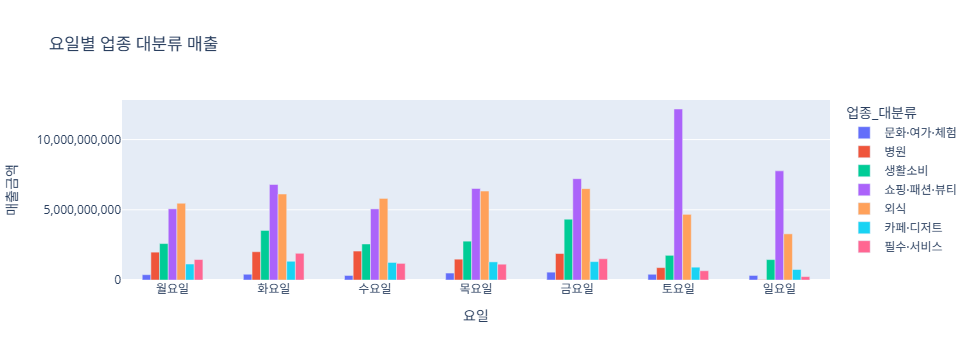

In [171]:
fig = px.bar(
    weekday_melt,
    x='요일',
    y='매출금액',
    color='업종_대분류',
    barmode='group',
    title='요일별 업종 대분류 매출'
)

fig.update_layout(
    bargap=0.4,
    yaxis_tickformat=','
)

fig.show()


In [172]:
weekday_total_sales = (
    weekday_melt
    .groupby('요일', as_index=False)['매출금액']
    .sum()
    .sort_values('요일')
)


C:\Users\BSY\AppData\Local\Temp\ipykernel_22448\1273909177.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [173]:
weekday_total_sales

,요일,매출금액
0,월요일,"18,084,165,784"
1,화요일,"22,113,914,885"
2,수요일,"18,255,976,378"
3,목요일,"20,011,663,471"
4,금요일,"23,318,717,962"
5,토요일,"21,473,037,494"
6,일요일,"13,853,583,381"


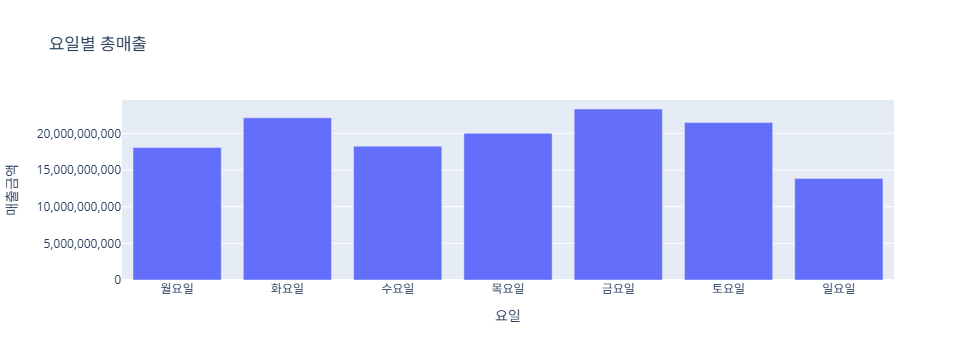

In [174]:


fig = px.bar(
    weekday_total_sales,
    x='요일',
    y='매출금액',
    title='요일별 총매출'
)

fig.update_layout(yaxis_tickformat=',')
fig.show()


In [175]:
df_cafe.head()

,Unnamed: 0,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,...,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,업종_대분류
207,557,20253,성수동카페거리,전자상거래업,"81,397,465",6375,"40,364,317","41,033,148","2,403,597","8,479,279",...,239,2021,4347,213,2575,1541,428,762,849,필수·서비스
208,558,20253,성수동카페거리,화장품,"1,860,437,864",60629,"1,527,904,685","332,533,179","54,607,444","526,918,948",...,0,12719,45931,2403,19786,17665,12438,4946,1414,쇼핑·패션·뷰티
209,559,20253,성수동카페거리,문구,"580,971,123",6353,"580,971,123",0,"92,739,412","187,120,215",...,0,1846,938,272,485,817,787,212,212,생활소비
210,560,20253,성수동카페거리,가방,"714,162,401",9508,"714,162,401",0,"363,475,792","115,431,354",...,0,4074,3260,0,0,1087,272,815,5162,쇼핑·패션·뷰티
211,561,20253,성수동카페거리,신발,"9,669,143,132",70806,"5,368,046,538","4,301,096,594","846,628,312","737,648,815",...,0,27064,40748,1953,21027,21879,13452,7132,2370,쇼핑·패션·뷰티


In [176]:
weekday_sales_cols = [
    '월요일_매출_금액',
    '화요일_매출_금액',
    '수요일_매출_금액',
    '목요일_매출_금액',
    '금요일_매출_금액',
    '토요일_매출_금액',
    '일요일_매출_금액'
]

weekday_total_sales = (
    df_cafe[weekday_sales_cols]
    .sum()
    .reset_index()
)

weekday_total_sales.columns = ['요일', '총매출금액']
weekday_total_sales

,요일,총매출금액
0,월요일_매출_금액,"4,408,185,492"
1,화요일_매출_금액,"6,057,375,978"
2,수요일_매출_금액,"4,243,027,686"
3,목요일_매출_금액,"5,563,621,147"
4,금요일_매출_금액,"6,529,616,376"
5,토요일_매출_금액,"10,240,680,122"
6,일요일_매출_금액,"6,610,276,448"


In [177]:
weekday_order =  [
    '월요일_매출_금액',
    '화요일_매출_금액',
    '수요일_매출_금액',
    '목요일_매출_금액',
    '금요일_매출_금액',
    '토요일_매출_금액',
    '일요일_매출_금액'
]

weekday_total_sales['요일'] = pd.Categorical(
    weekday_total_sales['요일'],
    categories=weekday_order,
    ordered=True
)

weekday_total_sales = weekday_total_sales.sort_values(by='총매출금액', ascending=False)

In [178]:
weekday_total_sales

,요일,총매출금액
5,토요일_매출_금액,"10,240,680,122"
6,일요일_매출_금액,"6,610,276,448"
4,금요일_매출_금액,"6,529,616,376"
1,화요일_매출_금액,"6,057,375,978"
3,목요일_매출_금액,"5,563,621,147"
0,월요일_매출_금액,"4,408,185,492"
2,수요일_매출_금액,"4,243,027,686"


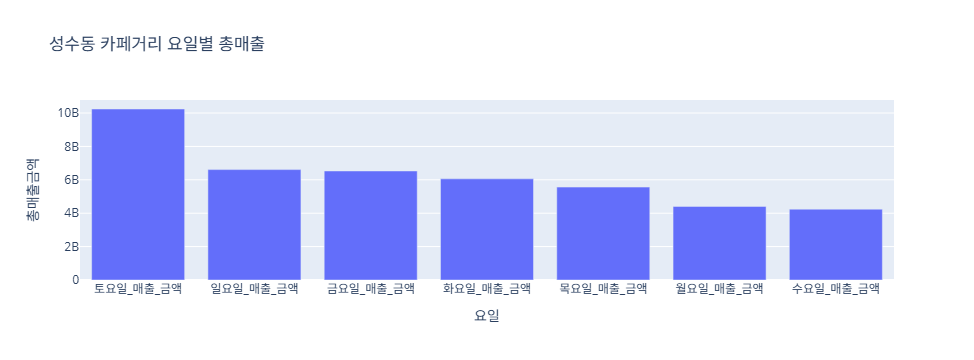

In [179]:
import plotly.express as px

px.bar(
    weekday_total_sales,
    x='요일',
    y='총매출금액',
    title='성수동 카페거리 요일별 총매출'
)


In [180]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. 대상 상권 필터링
# -----------------------------
df_target = df1[df1['상권_코드_명'].isin(['성수역','성수동카페거리'])].copy()

# -----------------------------
# 2. 요일별, 타깃 연령대 컬럼
# -----------------------------
요일_cols = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액',
             '목요일_매출_금액','금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']

target_age_cols = ['연령대_20_매출_금액','연령대_30_매출_금액']  # 타깃 20~30대

# -----------------------------
# 3. 타깃 연령대 로그 변환
# -----------------------------
# 0 대비 안정화 위해 +1
df_target['타깃_합'] = df_target[target_age_cols].sum(axis=1)
df_target['타깃_로그'] = np.log1p(df_target['타깃_합'])

# 로그 변환 결과 출력
print("20~30대 매출 로그 변환 결과:")
print(df_target[['상권_코드_명','타깃_합','타깃_로그']])

# -----------------------------
# 4. 요일별 매출 × 타깃 로그
# -----------------------------
df_target_요일 = df_target.copy()
for col in 요일_cols:
    df_target_요일[col] = df_target_요일[col] * df_target_요일['타깃_로그']

# -----------------------------
# 5. 두 상권 합산
# -----------------------------
df_통합 = df_target_요일.groupby('상권_코드_명')[요일_cols].sum()
df_통합_전체 = df_통합.sum()  # 두 상권 합산

# -----------------------------
# 6. 상위 요일 추천
# -----------------------------
추천_요일 = df_통합_전체.sort_values(ascending=False)
print("\n팝업 추천 요일 상위 3:")
print(추천_요일)


20~30대 매출 로그 변환 결과:
     상권_코드_명          타깃_합  타깃_로그
119      성수역   118,073,963     19
120      성수역     5,850,509     16
121      성수역     1,244,748     14
122      성수역    31,334,670     17
123      성수역    97,346,909     18
..       ...           ...    ...
223  성수동카페거리    82,560,174     18
224  성수동카페거리    44,564,887     18
225  성수동카페거리   502,251,687     20
226  성수동카페거리   184,852,614     19
227  성수동카페거리 2,513,191,589     22

[61 rows x 3 columns]

팝업 추천 요일 상위 3:
토요일_매출_금액   385,686,382,418
금요일_매출_금액   350,934,167,963
화요일_매출_금액   325,433,238,030
목요일_매출_금액   317,854,998,005
수요일_매출_금액   281,756,899,642
월요일_매출_금액   278,461,237,034
일요일_매출_금액   251,967,175,713
dtype: float64


In [181]:
df_target.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액',
       '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액', '화요일_매출_금액',
       '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액',
       '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수', '업종_대분류', '타깃_합', '타깃_로그'],
      dtype='object')

In [182]:
df_target['타깃_합'].describe()

count               61
mean       789,760,321
std      1,795,595,390
min                  0
25%         31,334,670
50%         98,568,355
75%        579,112,798
max     10,314,120,041
Name: 타깃_합, dtype: float64

In [183]:
df_target['월요일_매출_금액'].describe()

count              61
mean      217,828,284
std       401,339,217
min                 0
25%        13,293,496
50%        54,607,444
75%       228,550,008
max     2,293,288,361
Name: 월요일_매출_금액, dtype: float64

In [184]:
# 상권별 2030 매출을 로그점수화: 상대적 점수 
# 요일별 매출에 곱함 : 절대적 점수
# 상권별 2030대의 요일별 매출을 구함